Import Libraries

In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading dataset
df = pd.read_csv('train.csv')
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## Data Processing 1

In [ ]:
# checking the shape of the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

The data is clean. It has no missing values and the data types are correctly loaded.

**Explaratory Data Analysis**

Looking at how the cateorical features relates with the target feature.

The feature is will_buy_EV

In [4]:
# drop id column
df.drop(columns='id', inplace=True)

1. *Age and target*

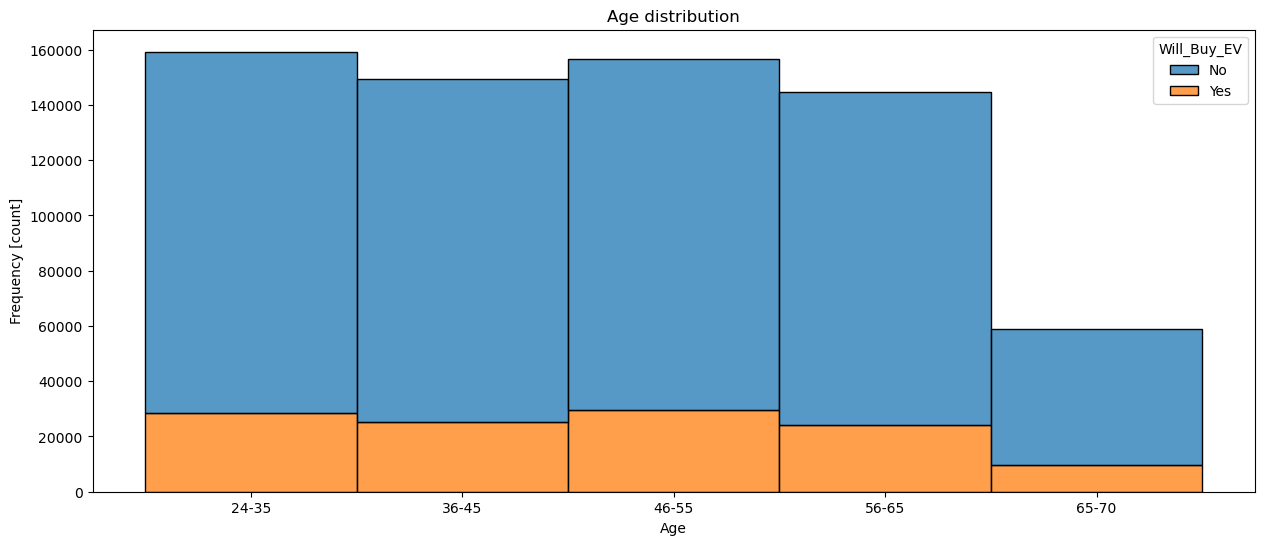

In [5]:
# age vs wil_buy_ev
fig, ax = plt.subplots(figsize=(15, 6))

# age is too spreadout to explore. We use age bracket instead of the normal age.
df['Age_group'] = pd.cut(df['Age'], bins=[24, 35, 45, 55, 65, 70], labels=['24-35', '36-45', '46-55', '56-65', '65-70' ])
sns.histplot(data=df, x='Age_group', hue='Will_Buy_EV', multiple='stack', ax=ax)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency [count]')
ax.set_title('Age distribution');

From the plot, it shows that people around the age of 46-55 will buy an EV. This are not relatively very young people so it means probabily these people are early millionaries. This set of people are also the highest in not purchasing the EV.

2. *Gender and target*

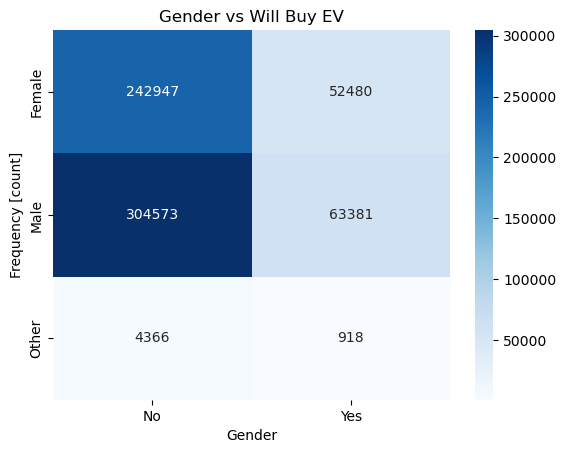

In [6]:
ct = pd.crosstab(df['Gender'], df['Will_Buy_EV'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Gender vs Will Buy EV')
plt.xlabel('Gender')
plt.ylabel('Frequency [count]')
plt.show()


The plot shows that the male have the highest number of people who are likely to buy a car which ranges around 6000 mean while the females have the low amount of about 5000.

3. *Number of cars owned*

Text(0.5, 1.0, 'Distribution: No of car vs Buy car')

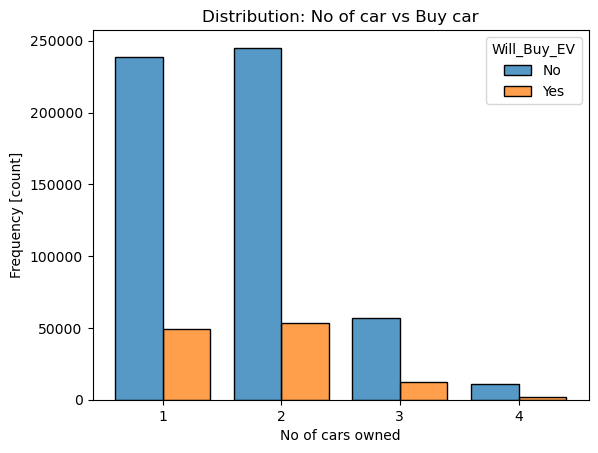

In [7]:
sns.histplot(
    data=df,
    x='Number_of_Cars_Owned',
    hue='Will_Buy_EV',
    multiple='dodge',
    discrete=True,
    shrink=0.8
)
plt.xticks([1, 2, 3, 4])
plt.xlabel('No of cars owned')
plt.ylabel('Frequency [count]')
plt.title('Distribution: No of car vs Buy car')

The plot shows that the number of people with 2 cars will most likely buy an EV car.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Age                          668665 non-null  int64   
 1   Annual_Income_USD            668665 non-null  float64 
 2   Daily_Commute_km             668665 non-null  float64 
 3   Number_of_Cars_Owned         668665 non-null  int64   
 4   Charging_Stations_Near_Home  668665 non-null  int64   
 5   Charging_Stations_Near_Work  668665 non-null  int64   
 6   Environmental_Concern_Level  668665 non-null  float64 
 7   Gender                       668665 non-null  object  
 8   City_Type                    668665 non-null  object  
 9   Current_Car_Type             668665 non-null  object  
 10  Home_Charging_Possible       668665 non-null  object  
 11  Subsidy_Available            668665 non-null  object  
 12  Range_Anxiety_Level          668665 non-null

4. Charging Stations near home

<Axes: xlabel='Charging_Stations_Near_Home', ylabel='count'>

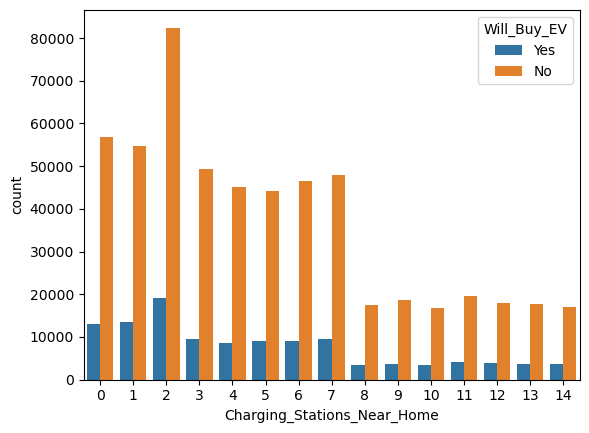

In [9]:
sns.countplot(
    data=df,
    x='Charging_Stations_Near_Home',
    hue='Will_Buy_EV',
)

5. Charging stations near work.

<Axes: xlabel='Charging_Stations_Near_Work', ylabel='count'>

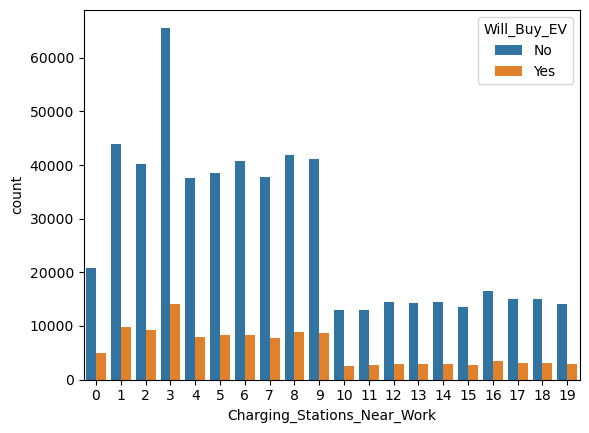

In [10]:
sns.countplot(
    data=df,
    x='Charging_Stations_Near_Work',
    hue='Will_Buy_EV',
)

In [11]:
df['Environmental_Concern_Level'].value_counts()

Environmental_Concern_Level
1.0    147476
2.0    135133
4.0    130469
5.0    128236
3.0    127351
Name: count, dtype: int64

6. Enviromental Concern Level

<Axes: xlabel='Environmental_Concern_Level', ylabel='count'>

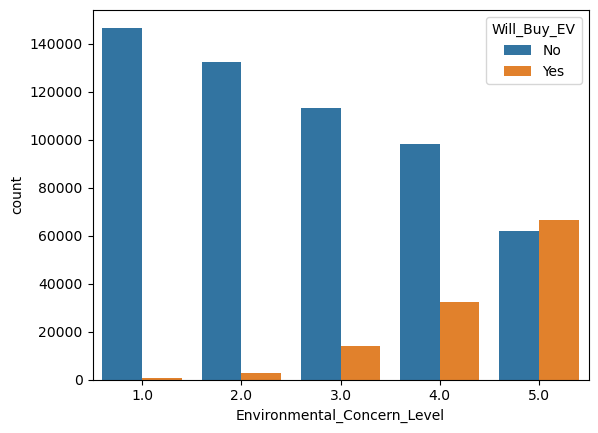

In [12]:
sns.countplot(
    data=df,
    x='Environmental_Concern_Level',
    hue='Will_Buy_EV',
)

In [13]:
# fig, ax = plt.subplots(figsize=(15, 6))

# sns.barplot(data=df, x='Annual_Income_USD', y= '', hue='Gender', errorbar=None);